# Cars4You - Handout Project | Group 42
## Bayes Search Notebook
**Course:** MSc in Data Science and Advanced Analytics, NOVA IMS (2025/2026)  

**Author(s):** Group 42
- `Miguel Matos - 20221925`
- `Andre Nicolau - 20221918`
- `André Ferreira - 20250398`


---

#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
1. [Imports](#Imports)  
2. [Modelling Testing](#modelling-testing) 
----

# Imports
[Back to TOC](#toc)

In [71]:
from utils.functions import *
from scipy.stats import randint
from sklearn.svm import LinearSVR
from utils.Nuestra_Pipeline import NuestraPipeline
from Preprocessing_pipelines.Outliers_pipeline import OutliersDealer
from Preprocessing_pipelines.Missing_Values_pipeline import MissingValuesDealer
from Preprocessing_pipelines.Encoding_pipeline import EncodingDealer
from Preprocessing_pipelines.Scaling_pipeline import ScalingDealer
from Preprocessing_pipelines.Feature_Selection_pipeline import FeatureSelectionDealer
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import warnings

# Suppress this specific warning
warnings.filterwarnings('ignore', 
                       message='X does not have valid feature names',
                       category=UserWarning,
                       module='sklearn.utils.validation')



data = pd.read_csv("../data/data_cleaned.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

In [72]:
data = data.sample(frac=1).reset_index(drop=True)

In [73]:
data.drop("paintQuality%", axis = 1, inplace= True)

In [74]:
X = data.drop("price", axis= 1)
y = data["price"]

# Random Forest

Loading the model with the best parameters from preprocess

In [6]:
rf_parameters = joblib.load('models/models_organized/models_preproc_tuning/rf_params.pkl')

Loading the best combination of parameters form the best estimator of Random forest using halving random search for tunning

In [7]:
RF_tuned = joblib.load('models/models_organized/models_tuning/rf_tuned.pkl')

In [10]:
RF_tuned.get_params()

{'encoder__cols': None,
 'encoder__handle_unknown': 'ignore',
 'encoder__method': 'target',
 'encoder__min_freq': 0,
 'encoder': EncodingDealer(method='target'),
 'imputer__fill_value': None,
 'imputer__imputation_method': 'knn_modelwise',
 'imputer__knn_neighbors': np.int64(13),
 'imputer__knn_scaling_method': 'robust',
 'imputer__min_model_size_for_knn': 15,
 'imputer__random_state': 42,
 'imputer__simple_strategy_num': 'mean',
 'imputer__strategy_cat': 'most_frequent',
 'imputer': MissingValuesDealer(imputation_method='knn_modelwise',
                     knn_neighbors=np.int64(13), knn_scaling_method='robust'),
 'model__bootstrap': True,
 'model__ccp_alpha': 0.0,
 'model__criterion': 'squared_error',
 'model__max_depth': 50,
 'model__max_features': 'sqrt',
 'model__max_leaf_nodes': 1000,
 'model__max_samples': 0.7,
 'model__min_impurity_decrease': 0.1,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 3,
 'model__min_weight_fraction_leaf': 0.0,
 'model__monotonic_cst': No

In [14]:
rf = RandomForestRegressor(verbose=3)

parameters = {
    # n_estimators: estava em 439, explorar 350-550
    "model__n_estimators": Integer(350, 550),
    
    # max_depth: estava em 50, explorar 40-70
    "model__max_depth": Integer(40, 70),
    
    # min_samples_split: estava em 3, explorar 2-6
    "model__min_samples_split": Integer(2, 6),
    
    # min_samples_leaf: estava em 4, explorar 2-8
    "model__min_samples_leaf": Integer(2, 8),
    
    # max_features: estava em 'sqrt', testar ao redor
    "model__max_features": Categorical(['sqrt', 'log2', 0.6, 0.7, 0.8]),
    
    # max_samples: estava em 0.7, explorar 0.6-0.9
    "model__max_samples": Real(0.6, 0.9, prior='uniform'),
    
    # min_impurity_decrease: estava em 0.1, explorar 0.05-0.2
    "model__min_impurity_decrease": Real(0.05, 0.2, prior='uniform'),
    
    # max_leaf_nodes: estava em 1000, explorar 700-1500
    "model__max_leaf_nodes": Integer(700, 1500),
    
    # criterion: manter squared_error e testar alternativas
    "model__criterion": Categorical(["squared_error", "friedman_mse"]),
    
    # ccp_alpha: estava em 0.0, testar pequenos valores
    "model__ccp_alpha": Real(0.0, 0.05, prior='uniform'),
    
    # Parâmetros fixos (já sabemos que funcionam bem)
    "model__bootstrap": Categorical([True]),
    "model__oob_score": Categorical([False]),
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

bayes_search_rf = BayesSearchCV(
    rf_parameters,
    parameters,
    n_iter=80,  # 80 iterações para refinamento
    scoring=mae_scorer,
    n_jobs=3,
    cv=3,
    verbose=3,
    random_state=42,
    n_points=3,  # Avaliar 3 pontos em paralelo
)

In [15]:
bayes_search_rf.fit(X,y)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fi

,estimator,NuestraPipeli...thod='model'))
,search_spaces,"{'model__bootstrap': Categorical(c...), prior=None), 'model__ccp_alpha': Real(low=0.0,...m='normalize'), 'model__criterion': Categorical(c...), prior=None), 'model__max_depth': Integer(low=4...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,80
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,3
,n_points,3
,iid,'deprecated'
,refit,True
,cv,3


In [23]:
rf_Bayes = pd.DataFrame(bayes_search_rf.cv_results_)
rf_Bayes.to_csv("../data/final_data/BS_models/RF_Bmodel.csv")

joblib.dump(bayes_search_rf.best_estimator_, 'models/models_organized/bayes_tuning/rf_Btuned.pkl')
rf_Bayes = joblib.load('models/models_organized/bayes_tuning/rf_Btuned.pkl')



In [24]:
rf_Bayes

,imputer,MissingValues...thod='robust')
,outlier_remover,"OutliersDeale...'tax', 'mpg'])"
,encoder,EncodingDeale...thod='target')
,scaler,ScalingDealer()
,selector,FeatureSelect...ethod='model')
,model,RandomForestR...ndom_state=42)
,q,10
,method,'target'
,cols,None
,handle_unknown,'ignore'
,min_freq,0


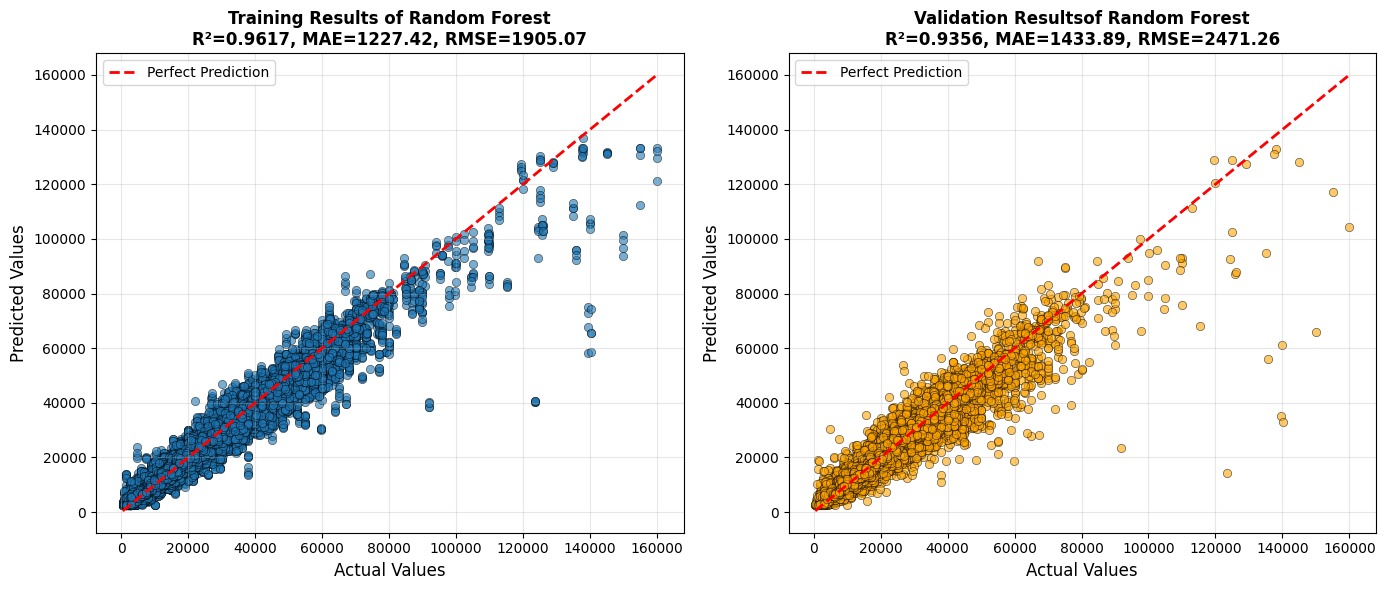

In [25]:
evaluate_best_model_with_cv(rf_Bayes, X, y,model_name= "Random Forest", cv=5)

In [29]:
rf_Bayes.get_params()

{'encoder__cols': None,
 'encoder__handle_unknown': 'ignore',
 'encoder__method': 'target',
 'encoder__min_freq': 0,
 'encoder': EncodingDealer(method='target'),
 'imputer__fill_value': None,
 'imputer__imputation_method': 'knn_modelwise',
 'imputer__knn_neighbors': np.int64(13),
 'imputer__knn_scaling_method': 'robust',
 'imputer__min_model_size_for_knn': 15,
 'imputer__random_state': 42,
 'imputer__simple_strategy_num': 'mean',
 'imputer__strategy_cat': 'most_frequent',
 'imputer': MissingValuesDealer(imputation_method='knn_modelwise',
                     knn_neighbors=np.int64(13), knn_scaling_method='robust'),
 'model__bootstrap': True,
 'model__ccp_alpha': 0.05,
 'model__criterion': 'squared_error',
 'model__max_depth': 40,
 'model__max_features': 0.6,
 'model__max_leaf_nodes': 1500,
 'model__max_samples': 0.9,
 'model__min_impurity_decrease': 0.2,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 6,
 'model__min_weight_fraction_leaf': 0.0,
 'model__monotonic_cst': None

Bayes search with the best model parameters in the preprocess parameters 

In [33]:
#parametros otimizados conseguidos na última search
rf_optimized = RandomForestRegressor(
    n_estimators=550,
    max_depth=40,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features=0.6,
    max_samples=0.9,
    min_impurity_decrease=0.2,
    max_leaf_nodes=1500,
    criterion='squared_error',
    bootstrap=True,
    ccp_alpha=0.05,
    oob_score=False,
    random_state=42,
    n_jobs=None,
    verbose=0,
    warm_start=False
)

rf_Bayes = NuestraPipeline(
    MissingValuesDealer(),
    OutliersDealer(
        mod_outliers_cols=["tax", "mpg"],        #fixar os valores destes parametros
        sev_outliers_cols=["car_age", "mileage", "engineSize"],
        z_columns=["car_age", "mileage", "tax", "mpg"],
        model_columns=["car_age", "mileage", "tax", "mpg"]
    ),
    EncodingDealer(),
    ScalingDealer(),
    FeatureSelectionDealer(),
    rf_optimized  # Modelo fixo com seus parâmetros
)



parameters = {
    # Imputer
    "imputer__imputation_method": Categorical(["knn_modelwise", "simple", "iterative"]),
    "imputer__knn_neighbors": Integer(5, 20),  # Em vez de np.arange(5,21)
    "imputer__knn_scaling_method": Categorical(["standard", "minmax", "robust"]),
    
    # Outlier Remover
    "outlier_remover__outlier_method": Categorical(["Isolation_Forest", "LOF", "IQR", "z_score"]), 
    "outlier_remover__threshold": Integer(2, 3),  # Em vez de [2, 3]
    "outlier_remover__contamination_IF": Real(0.05, 0.5, prior='uniform'),
    "outlier_remover__n_neighbors": Integer(30, 100),
    "outlier_remover__contamination_LOF": Real(0.05, 0.5, prior='uniform'),
    
    # Encoder
    "encoder__method": Categorical(["target", "freq"]),
    
    # Scaler
    "scaler__scaler_name": Categorical(["robust", "minmax", "standard"]),
    
    # Feature Selection
    "selector__selection_method": Categorical(["kbest", "model", "rfe"]),
    "selector__k": Integer(5, 10),  # Em vez de np.arange(5,11)
    "selector__model_name": Categorical(["rf"]),
    "selector__n_features_to_select": Integer(5, 10),
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

bayes_search_rf_params = BayesSearchCV(
    rf_Bayes,
    parameters,
    n_iter=80,  # 80 iterações para refinamento
    scoring=mae_scorer,
    n_jobs=3,
    cv=3,
    verbose=3,
    random_state=42,
    n_points=3,  # Avaliar 3 pontos em paralelo
)

In [34]:
bayes_search_rf_params.fit(X,y)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Fitting 3 folds for each of 3 candidates, totalling 9 fi

,estimator,NuestraPipeli...ctionDealer())
,search_spaces,"{'encoder__method': Categorical(c...), prior=None), 'imputer__imputation_method': Categorical(c...), prior=None), 'imputer__knn_neighbors': Integer(low=5...m='normalize'), 'imputer__knn_scaling_method': Categorical(c...), prior=None), ...}"
,optimizer_kwargs,None
,n_iter,80
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,3
,n_points,3
,iid,'deprecated'
,refit,True
,cv,3


In [35]:
rf_Bayes2 = pd.DataFrame(bayes_search_rf_params.cv_results_)
rf_Bayes2.to_csv("../data/final_data/BS_models/RF_Bmodel2.csv")

joblib.dump(bayes_search_rf_params.best_estimator_, 'models/models_organized/bayes_tuning/rf_Btuned2.pkl')
rf_Bayes2 = joblib.load('models/models_organized/bayes_tuning/rf_Btuned2.pkl')

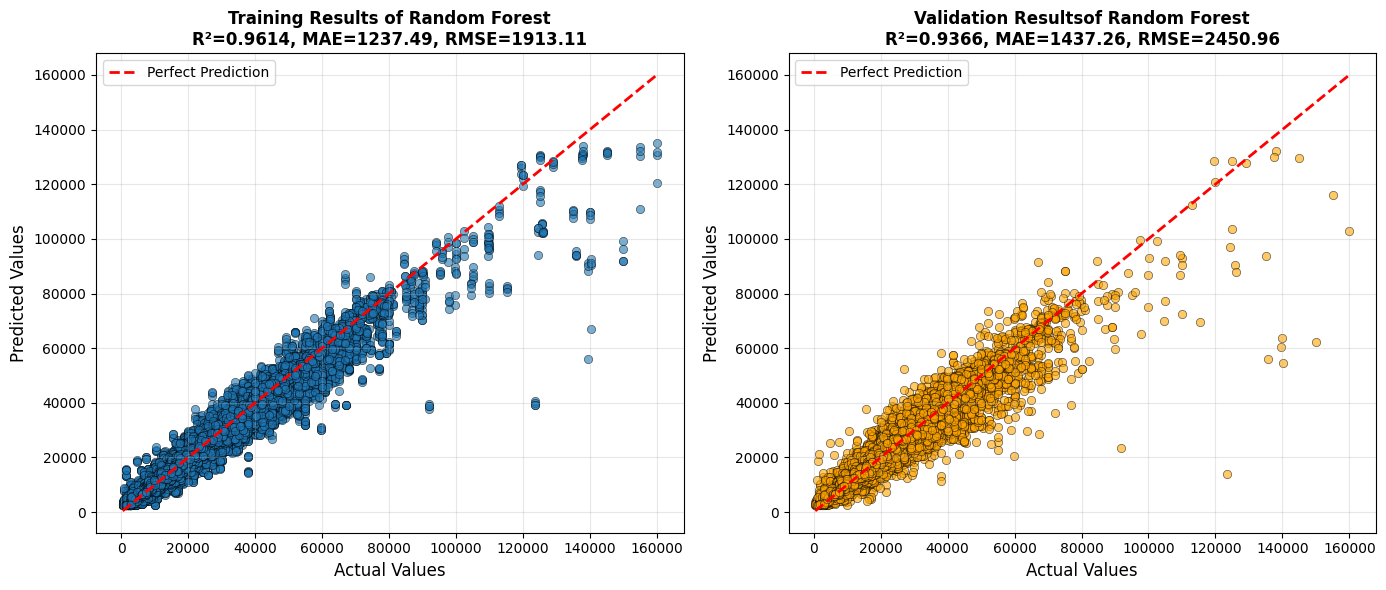

In [36]:
evaluate_best_model_with_cv(rf_Bayes2, X, y,model_name= "Random Forest", cv=5)

# Hist Gradient Boosting

In [37]:
HGB_tuned = joblib.load('models/models_organized/models_tuning/hgb_tuned.pkl')

In [38]:
HGB_tuned.get_params()

{'encoder__cols': None,
 'encoder__handle_unknown': 'ignore',
 'encoder__method': 'target',
 'encoder__min_freq': 0,
 'encoder': EncodingDealer(method='target'),
 'imputer__fill_value': None,
 'imputer__imputation_method': 'iterative',
 'imputer__knn_neighbors': np.int64(20),
 'imputer__knn_scaling_method': 'robust',
 'imputer__min_model_size_for_knn': 15,
 'imputer__random_state': 42,
 'imputer__simple_strategy_num': 'mean',
 'imputer__strategy_cat': 'most_frequent',
 'imputer': MissingValuesDealer(imputation_method='iterative', knn_neighbors=np.int64(20),
                     knn_scaling_method='robust'),
 'model__categorical_features': 'from_dtype',
 'model__early_stopping': 'auto',
 'model__interaction_cst': None,
 'model__l2_regularization': 10.0,
 'model__learning_rate': 0.1,
 'model__loss': 'squared_error',
 'model__max_bins': 255,
 'model__max_depth': None,
 'model__max_features': 1.0,
 'model__max_iter': 100,
 'model__max_leaf_nodes': None,
 'model__min_samples_leaf': 10,
 'mo

In [40]:
hgb_parameters = joblib.load('models/models_organized/models_preproc_tuning/hgb_params.pkl')


In [44]:

parameters = {
    # ========== PARÂMETROS PRINCIPAIS ==========
    
    # learning_rate: estava em 0.1, explorar 0.05-0.2
    "model__learning_rate": Real(0.05, 0.2, prior='log-uniform'),
    
    # max_iter: estava em 100, explorar 80-150
    "model__max_iter": Integer(80, 150),
    
    # max_depth: estava em None, testar valores específicos + None
    "model__max_depth": Categorical([None, 5, 7, 10, 15]),
    
    # min_samples_leaf: estava em 10, explorar 5-20
    "model__min_samples_leaf": Integer(5, 20),
    
    # l2_regularization: estava em 10.0, explorar 1-20
    "model__l2_regularization": Real(1.0, 20.0, prior='log-uniform'),
    
    # max_leaf_nodes: estava em None, testar valores + None
    "model__max_leaf_nodes": Categorical([None, 20, 31, 50, 100]),
    
    # max_bins: estava em 255 (máximo), testar valores menores
    "model__max_bins": Integer(200, 255),
    
    # max_features: estava em 1.0, explorar 0.7-1.0
    "model__max_features": Real(0.7, 1.0, prior='uniform'),
    
    # ========== EARLY STOPPING ==========
    
    # early_stopping: estava em 'auto', testar True/False também
    "model__early_stopping": Categorical(['auto', True, False]),
    
    # n_iter_no_change: estava em 10, explorar 5-15
    "model__n_iter_no_change": Integer(5, 15),
    
    # validation_fraction: estava em 0.1, explorar 0.05-0.2
    "model__validation_fraction": Real(0.05, 0.2, prior='uniform'),
    
    # tol: estava em 1e-07, explorar tolerâncias
    "model__tol": Real(1e-08, 1e-05, prior='log-uniform'),
    
    # ========== OUTROS PARÂMETROS ==========
    
    # loss: manter squared_error e testar alternativas
    "model__loss": Categorical(['squared_error', 'poisson']),
    
    # scoring: manter 'loss' (padrão)
    "model__scoring": Categorical(['loss']),
    
    # Parâmetros fixos (já ótimos)
    "model__categorical_features": Categorical(['from_dtype']),
    "model__warm_start": Categorical([False]),
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

bayes_search_hgb = BayesSearchCV(
    hgb_parameters,
    parameters,
    n_iter=200,  # 80 iterações para refinamento
    scoring=mae_scorer,
    n_jobs=3,
    cv=3,
    verbose=3,
    random_state=42,
    n_points=1,  # Avaliar 3 pontos em paralelo
)

In [45]:
bayes_search_hgb.fit(X,y)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

,estimator,NuestraPipeli...thod='kbest'))
,search_spaces,"{'model__categorical_features': Categorical(c...), prior=None), 'model__early_stopping': Categorical(c...), prior=None), 'model__l2_regularization': Real(low=1.0,...m='normalize'), 'model__learning_rate': Real(low=0.05...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,200
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,3
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [46]:
hgb_Bayes = pd.DataFrame(bayes_search_hgb.cv_results_)
hgb_Bayes.to_csv("../data/final_data/BS_models/HGB_Bmodel.csv")

joblib.dump(bayes_search_hgb.best_estimator_, 'models/models_organized/bayes_tuning/hgb_Btuned.pkl')
hgb_Bayes = joblib.load('models/models_organized/bayes_tuning/hgb_Btuned.pkl')

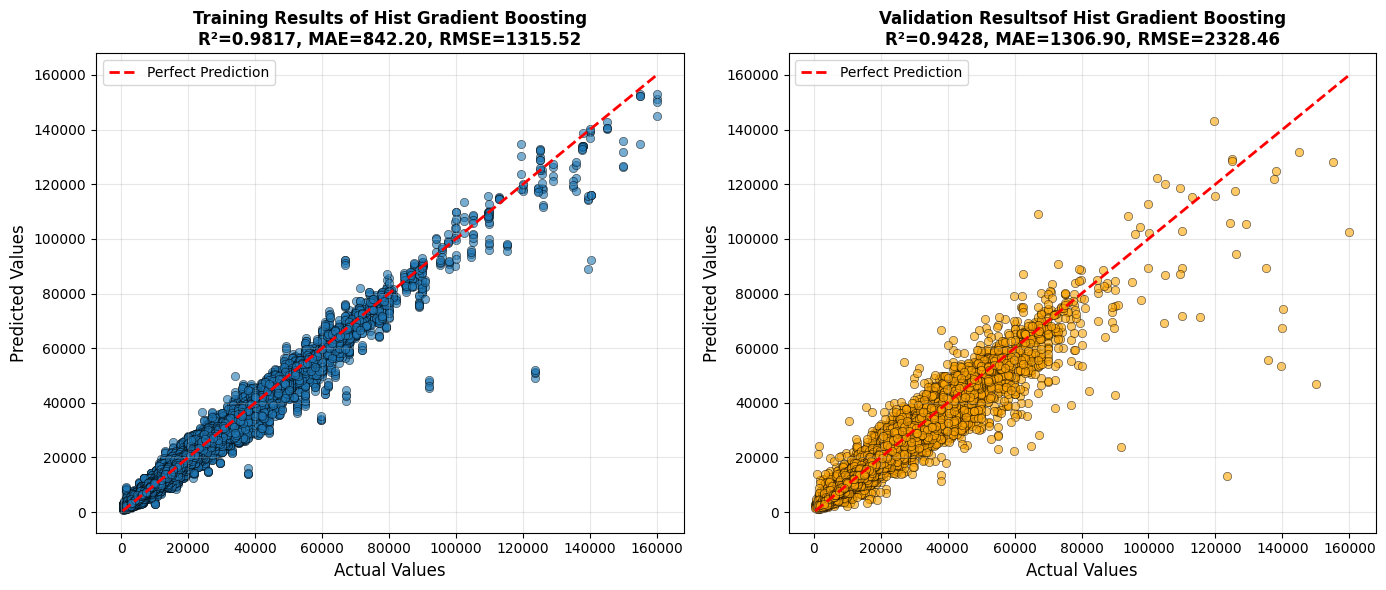

In [47]:
evaluate_best_model_with_cv(hgb_Bayes, X, y,model_name= "Hist Gradient Boosting", cv=5)

In [48]:
hgb_Bayes.get_params()

{'encoder__cols': None,
 'encoder__handle_unknown': 'ignore',
 'encoder__method': 'target',
 'encoder__min_freq': 0,
 'encoder': EncodingDealer(method='target'),
 'imputer__fill_value': None,
 'imputer__imputation_method': 'iterative',
 'imputer__knn_neighbors': np.int64(20),
 'imputer__knn_scaling_method': 'robust',
 'imputer__min_model_size_for_knn': 15,
 'imputer__random_state': 42,
 'imputer__simple_strategy_num': 'mean',
 'imputer__strategy_cat': 'most_frequent',
 'imputer': MissingValuesDealer(imputation_method='iterative', knn_neighbors=np.int64(20),
                     knn_scaling_method='robust'),
 'model__categorical_features': 'from_dtype',
 'model__early_stopping': False,
 'model__interaction_cst': None,
 'model__l2_regularization': 7.383650275495121,
 'model__learning_rate': 0.07910804314767905,
 'model__loss': 'squared_error',
 'model__max_bins': 238,
 'model__max_depth': 15,
 'model__max_features': 0.7,
 'model__max_iter': 150,
 'model__max_leaf_nodes': None,
 'model__m

Now we will try a solution anti-overfitting

In [49]:
parameters_anti_overfit = {
    # EARLY STOPPING (SEMPRE ATIVO!)
    "model__early_stopping": Categorical([True]),
    "model__n_iter_no_change": Integer(8, 15),
    "model__validation_fraction": Real(0.1, 0.2, prior='uniform'),
    
    # CONTROLAR COMPLEXIDADE (ranges conservadores)
    "model__max_depth": Integer(5, 10),  # Não deixar passar de 10!
    "model__max_leaf_nodes": Categorical([20, 31, 50, 100]),
    "model__min_samples_leaf": Integer(10, 30),  # Folhas maiores
    
    # REGULARIZAÇÃO FORTE
    "model__l2_regularization": Real(10.0, 30.0, prior='log-uniform'),
    
    # LEARNING RATE BAIXO
    "model__learning_rate": Real(0.03, 0.08, prior='log-uniform'),
    "model__max_iter": Integer(150, 250),  # OK com early stopping
    
    # Feature subsampling
    "model__max_features": Real(0.6, 0.8, prior='uniform'),
    
    # Manter fixos
    "model__max_bins": Categorical([238]),
    "model__loss": Categorical(['squared_error']),
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

bayes_search_hgb2 = BayesSearchCV(
    hgb_parameters,
    parameters_anti_overfit,
    n_iter=80,  # 80 iterações para refinamento
    scoring=mae_scorer,
    n_jobs=3,
    cv=5,
    verbose=3,
    random_state=42,
    n_points=1,  # Avaliar 3 pontos em paralelo
)

In [50]:
bayes_search_hgb2.fit(X,y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(7), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(8), 0.1] before, using random point [True, 23.39964376524445, 0.04107586857795234, 'squared_error', 238, np.int64(8), 0.6234956907456806, np.int64(200), 100, np.int64(19), np.int64(12), 0.1594895547493703]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(8), 0.1] before, using random point [True, 24.343716965968845, 0.075137336674371, 'squared_error', 238, np.int64(5), 0.7223675031370742, np.int64(206), 31, np.int64(20), np.int64(14), 0.19700146827647458]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(8), 0.1] before, using random point [True, 15.08897316230273, 0.0642211576823457, 'squared_error', 238, np.int64(6), 0.6789363670850419, np.int64(160), 100, np.int64(24), np.int64(9), 0.11881423971345648]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(12), 0.1] before, using random point [True, 17.38448027187098, 0.054416989164061805, 'squared_error', 238, np.int64(6), 0.75787804033911, np.int64(227), 31, np.int64(29), np.int64(14), 0.14461825135596232]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(15), 0.1] before, using random point [True, 13.746051077719544, 0.060337857712671854, 'squared_error', 238, np.int64(10), 0.6801676977286923, np.int64(198), 20, np.int64(13), np.int64(11), 0.16282865911597738]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(15), 0.1] before, using random point [True, 13.319453202023135, 0.07146225755882601, 'squared_error', 238, np.int64(9), 0.7171691105295687, np.int64(171), 50, np.int64(29), np.int64(11), 0.14061651548886672]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(15), 0.1] before, using random point [True, 29.618175027661685, 0.05354877170498821, 'squared_error', 238, np.int64(8), 0.6004776463787502, np.int64(223), 100, np.int64(14), np.int64(8), 0.10637137713615102]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(9), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(13), 0.1] before, using random point [True, 21.37752646374347, 0.04095098801248552, 'squared_error', 238, np.int64(8), 0.6424133302544828, np.int64(182), 31, np.int64(24), np.int64(9), 0.14264895326524915]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(10), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(15), 0.1] before, using random point [True, 16.879155006494948, 0.05121987546813999, 'squared_error', 238, np.int64(8), 0.7379618616730197, np.int64(216), 100, np.int64(22), np.int64(13), 0.1898388185897167]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.True_, 10.0, 0.07999999999999999, np.str_('squared_error'), np.int64(238), np.int64(10), 0.8, np.int64(250), np.int64(100), np.int64(10), np.int64(15), 0.1] before, using random point [True, 17.693030945311605, 0.05737806207948085, 'squared_error', 238, np.int64(6), 0.794541160783456, np.int64(222), 50, np.int64(13), np.int64(15), 0.14978056785589047]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,NuestraPipeli...thod='kbest'))
,search_spaces,"{'model__early_stopping': Categorical(c...), prior=None), 'model__l2_regularization': Real(low=10.0...m='normalize'), 'model__learning_rate': Real(low=0.03...m='normalize'), 'model__loss': Categorical(c...), prior=None), ...}"
,optimizer_kwargs,None
,n_iter,80
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,3
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [51]:
hgb_Bayes2 = pd.DataFrame(bayes_search_hgb2.cv_results_)
hgb_Bayes2.to_csv("../data/final_data/BS_models/HGB_Bmodel2.csv")

joblib.dump(bayes_search_hgb2.best_estimator_, 'models/models_organized/bayes_tuning/hgb_Btuned2.pkl')
hgb_Bayes2 = joblib.load('models/models_organized/bayes_tuning/hgb_Btuned2.pkl')

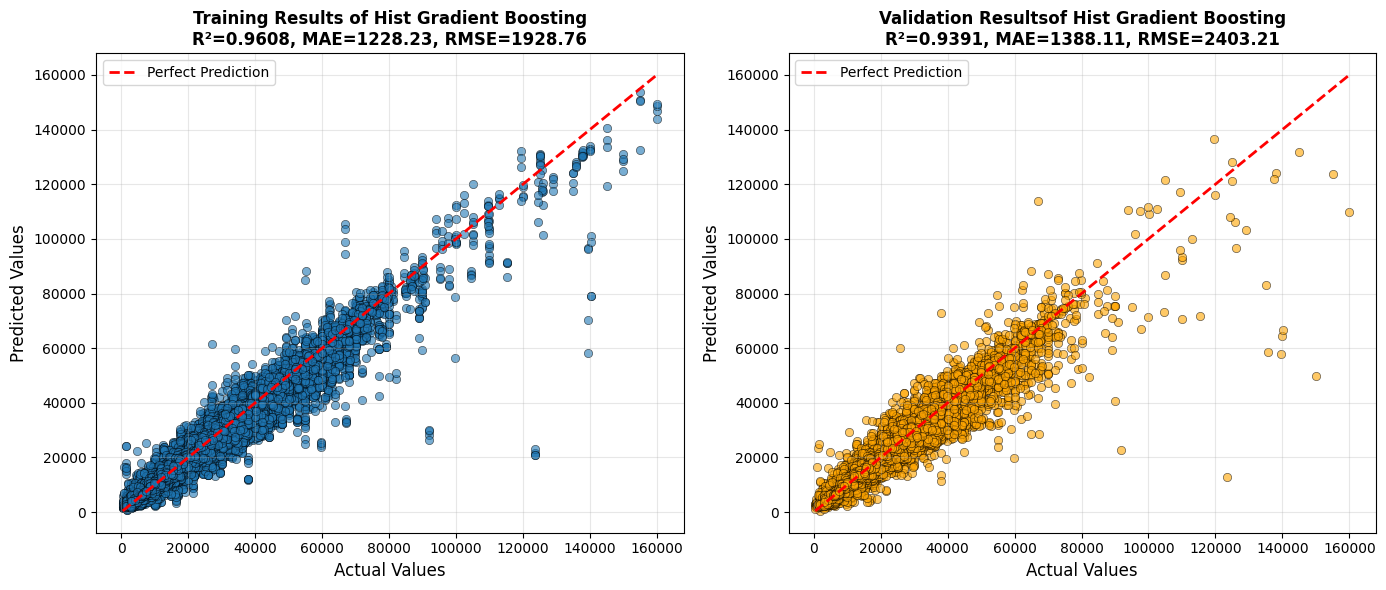

In [53]:
evaluate_best_model_with_cv(hgb_Bayes2, X, y,model_name= "Hist Gradient Boosting", cv=5)

We got a good model, but we can observe that the prices that our model is getting more wrong are prices, from expensive cars, so we will try other loss functions on histgradientboost to try to mitigate this factor and improve the scoring 

In [62]:
parameters = {
    "model__loss": Categorical(["quantile"]),
    "model__quantile": Real(0.7,0.98)
}

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

bayes_search_hgb3 = BayesSearchCV(
    hgb_Bayes2,
    parameters,
    n_iter=80,  # 80 iterações para refinamento
    scoring=mae_scorer,
    n_jobs=3,
    cv=5,
    verbose=3,
    random_state=42,
    n_points=1,  # Avaliar 3 pontos em paralelo
)

In [63]:
bayes_search_hgb3.fit(X,y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9603320111819633]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8301085031001413]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8848859261528665]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9602231366348823]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8712884605138338]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7988037054176509]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7229639155152483]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7130190639884262]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7117744621455002]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9604463325647489]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9701905146340425]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8941108880857522]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.799659968430745]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8180357813887889]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9199201829490872]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8688211991521074]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7884298642528433]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7980524955875165]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8803129307750287]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9399934451514705]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7922582651305441]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9452323387023368]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7380694475468471]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8637668835643402]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8689219067254204]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9033244821711237]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7375211807564214]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8227059645813337]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8941153324223139]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9657774780939037]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8879884791268688]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7017543527412509]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9311130211448848]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8435907868615369]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7971788997446438]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8661462914371819]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8757683602724183]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8930956695861137]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.733273656309898]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8688664525910059]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9103026446066401]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7215516378279119]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8725113264354929]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8691144763632008]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.859138600447292]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7502344830100531]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.940876066925601]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.827616999554003]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9679225251975083]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.705214815499716]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9647655640259585]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7597177227774969]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9177517198650119]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7227286733355265]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7422316610050552]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7530825004022266]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7440043617285793]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.938575855050551]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9023509055671189]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7286397660995793]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.8231338254143072]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9508664937046929]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7804377305347703]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9136165966804145]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9063663067936907]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.9368669667887828]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7703109381092559]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('quantile'), 0.7] before, using random point ['quantile', 0.7171613262800891]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,NuestraPipeli...thod='kbest'))
,search_spaces,"{'model__loss': Categorical(c...), prior=None), 'model__quantile': Real(low=0.7,...m='normalize')}"
,optimizer_kwargs,None
,n_iter,80
,scoring,make_scorer(m...hod='predict')
,fit_params,None
,n_jobs,3
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [64]:
hgb_Bayes3 = pd.DataFrame(bayes_search_hgb3.cv_results_)
hgb_Bayes3.to_csv("../data/final_data/BS_models/HGB_Bmodel3.csv")

joblib.dump(bayes_search_hgb3.best_estimator_, 'models/models_organized/bayes_tuning/hgb_Btuned3.pkl')
hgb_Bayes3 = joblib.load('models/models_organized/bayes_tuning/hgb_Btuned3.pkl')

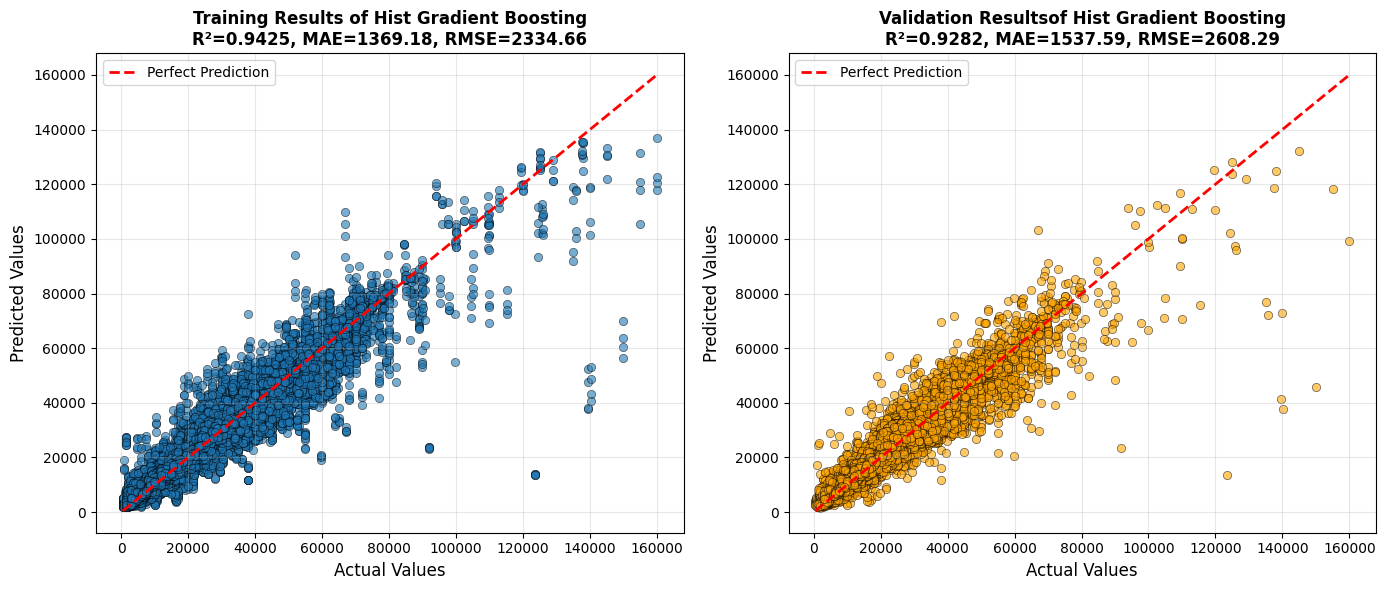

In [65]:
evaluate_best_model_with_cv(hgb_Bayes3, X, y,model_name= "Hist Gradient Boosting", cv=5)

We don't got a better result

# Getting results from the test data set

First we have to clean the data of the test dataset

In [83]:
data = pd.read_csv("../data/test.csv", index_col= "carID")
pd.set_option("display.max_columns", None)

### "year"

In [84]:
data["year"] = np.clip(data["year"], 0, 2020)

In [85]:
data["year"] = data["year"].apply(lambda x: math.floor(x) if pd.notna(x) else x)
data["year"].describe()

count    31914.000000
mean      2017.080278
std          2.175345
min       1991.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2020.000000
Name: year, dtype: float64

In [86]:
data["year"] = 2020 - data["year"]
data.rename(columns={"year": "car_age"}, inplace= True)
data

,Brand,model,car_age,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I30,0.0,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
106581,VW,Tiguan,3.0,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
80886,BMW,2 Series,4.0,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
100174,Opel,Grandland X,1.0,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
81376,BMW,1 Series,1.0,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,3.0,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0,0.0
81363,BMW,X2,0.0,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0,0.0
76833,Audi,Q5,1.0,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0,0.0


### "mileage"

In [87]:
data.loc[data["mileage"] < 0, "mileage"] = np.nan

### "tax"

In [88]:
data.loc[data["tax"] < 0, "tax"] = np.nan

### "mpg"

In [89]:
data.loc[data["mpg"] < 0, "mpg"] = np.nan

### "engineSize"

In [90]:
data.loc[data["engineSize"] < 0, "engineSize"] = np.nan

In [91]:
data.loc[data["engineSize"] == 0, "engineSize"] = np.nan

### "paintQuality%"

In [92]:
data.drop("paintQuality%", axis = 1, inplace= True)

### "previousOwners"

In [93]:
data.loc[data["previousOwners"] < 0, "previousOwners"] = np.nan

In [94]:
data["previousOwners"] = data["previousOwners"].apply(lambda x: math.floor(x) if pd.notna(x) else x)
data["previousOwners"].describe()

count    31802.000000
mean         2.027703
std          1.438231
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: previousOwners, dtype: float64

### "hasDamage"

In [95]:
data.drop("hasDamage", axis = 1, inplace= True)

#### Text normalization for categorical variables cleaning

In [96]:
data["model"] = data["model"].apply(normalize_text)
data["Brand"] = data["Brand"].apply(normalize_text)
data["transmission"] = data["transmission"].apply(normalize_text)
data["fuelType"] = data["fuelType"].apply(normalize_text)

### "brand" variable cleaning

In [97]:
correct_brands = {"Audi": ['aud', 'audi', 'udi', 'ud'],
                  "BMW": ['bmw', 'mw', 'bm'],
                  "Ford": ['ford', 'for', 'ord', 'or'],
                  "Hyundai" : ['hyundai', 'hyunda', 'yundai', 'yunda'],
                  "Mercedes" : ['mercedes','ercedes', 'mercede', 'ercede'],
                  "Skoda": ['skoda', 'koda', 'skod', 'kod'],
                  "Toyota": ['toyota', 'toyot', 'oyota'],
                  "Opel": ['opel', 'pel', 'ope', 'pe'],
                  "VW": ['vw', 'w','v']}

variant_to_brand = {variant: brand for brand, variants in correct_brands.items() for variant in variants}
data["Brand"] = data["Brand"].map(variant_to_brand)
data["Brand"].unique()

array(['Hyundai', 'VW', 'BMW', 'Opel', 'Ford', 'Mercedes', 'Skoda',
       'Toyota', 'Audi', nan], dtype=object)

### "model" variable cleaning

In [98]:
models_per_brand = pd.DataFrame(data.groupby(by =["Brand"])["model"].unique())
models_per_brand["model"] = models_per_brand["model"].apply(lambda x: [model for model in x if pd.notna(model)])
models_per_brand

,model
Brand,
Audi,"[tt, a4, a7, q2, a1, q5, a3, q3, q, a5, a6, a8..."
BMW,"[2 series, 1 series, x1, 5 series, 3 series, 4..."
Ford,"[fiesta, focus, ecosport, kuga, grand c-max, k..."
Hyundai,"[i30, ix20, i10, tucson, i40, ix35, i20, santa..."
Mercedes,"[b class, c class, m clas, e class, a class, x..."
Opel,"[grandland x, adam, zafira, corsa, insignia, m..."
Skoda,"[superb, fabia, octavia, karoq, kamiq, kodiaq,..."
Toyota,"[aygo, land cruiser, yaris, rav4, auris, corol..."
VW,"[tiguan, up, golf, passat, caravelle, polo, sh..."


In [99]:
models_per_brand["model"] = models_per_brand["model"].apply(lambda x: [re.sub(r'\bclas\b', 'class', str(model)) for model in x])
models_per_brand

,model
Brand,
Audi,"[tt, a4, a7, q2, a1, q5, a3, q3, q, a5, a6, a8..."
BMW,"[2 series, 1 series, x1, 5 series, 3 series, 4..."
Ford,"[fiesta, focus, ecosport, kuga, grand c-max, k..."
Hyundai,"[i30, ix20, i10, tucson, i40, ix35, i20, santa..."
Mercedes,"[b class, c class, m class, e class, a class, ..."
Opel,"[grandland x, adam, zafira, corsa, insignia, m..."
Skoda,"[superb, fabia, octavia, karoq, kamiq, kodiaq,..."
Toyota,"[aygo, land cruiser, yaris, rav4, auris, corol..."
VW,"[tiguan, up, golf, passat, caravelle, polo, sh..."


In [100]:
brands = models_per_brand.index.tolist()

for models, brand in zip(models_per_brand["model"], brands):
    canonical_names = {}  # to store canonical form for each variant

    for model in models:
        if model in canonical_names:
            continue  # already assigned

        # adaptive threshold
        threshold = 90 if len(model) < 4 else 75

        # find similar models within this brand
        matches = process.extract(model, models, scorer=fuzz.token_sort_ratio)
        close = [m for m, score, _ in matches if score >= threshold]
        for c in close:
            canonical_names[c] = model  # group under canonical name

    data.loc[data["Brand"] == brand , "model"] = data.loc[data["Brand"] == brand, "model"].map(canonical_names).fillna(data.loc[data["Brand"] == brand, "model"])

data["model"] = data["model"].str.capitalize()

### "fuelType" variable cleaning

In [101]:
correct_fueltype = {"Diesel": ["diesel", "iesel", "diese", "iese"],
                    "Petrol": ["petrol", "petro", "etrol", "etro"],
                    "Hybrid": ["hybrid", "ybrid", "hybri", "ybri"],
                    "Other": ["other", "ther", "othe"],
                    "Eletric": "eletric"}

variant_to_fuelType = {variant: fuelType for fuelType, variants in correct_fueltype.items() for variant in variants}
data["fuelType"] = data["fuelType"].map(variant_to_fuelType)
data["fuelType"].unique()

array(['Petrol', 'Diesel', 'Hybrid', nan, 'Other'], dtype=object)

### "transmission" variable cleaning

In [102]:
correct_transmissions = {
    "Manual": ["manual", "anual", "manua", "anua"],
    "Semi-Auto": ["semi-auto", "emi-auto", "semi-aut", "emi-aut"],
    "Automatic": ["automatic", "automati", "utomatic", "utomati"],
    "Unknown": ["unknown", "unknow", "nknown", "nknow"],"Other": ["other"]}

variant_to_transmissions = {variant: transmissions for transmissions, variants in correct_transmissions.items() for variant in variants}
data["transmission"] = data["transmission"].map(variant_to_transmissions)
data["transmission"].unique()

array(['Automatic', 'Semi-Auto', 'Manual', 'Unknown', nan, 'Other'],
      dtype=object)

### "Brand" missing values filling

In [103]:
brand_per_model = (
    data.groupby("model")["Brand"]
        .unique()                       # get unique brands per model (still lists)
        .apply(lambda x: [b for b in x if pd.notna(b)])  # remove NaNs
        .apply(lambda x: x[0] if len(x) > 0 else None) # take first brand as string
        .to_dict()                        # convert to dictionary
)

brand_per_model

{'1 series': None,
 '180': 'Mercedes',
 '2 series': None,
 '3 serie': 'BMW',
 '3 series': None,
 '4 series': 'BMW',
 '5 serie': 'BMW',
 '5 series': None,
 '6 series': 'BMW',
 '7 series': 'BMW',
 '8 series': 'BMW',
 'A': 'Audi',
 'A clas': 'Mercedes',
 'A class': None,
 'A1': 'Audi',
 'A3': 'Audi',
 'A4': 'Audi',
 'A5': 'Audi',
 'A6': 'Audi',
 'A7': 'Audi',
 'A8': 'Audi',
 'Adam': 'Opel',
 'Agila': 'Opel',
 'Amarok': 'VW',
 'Amica': None,
 'Ampera': 'Opel',
 'Antara': 'Opel',
 'Arteon': 'VW',
 'Astra': 'Opel',
 'Auri': 'Toyota',
 'Auris': None,
 'Avensis': 'Toyota',
 'Aygo': 'Toyota',
 'B clas': 'Mercedes',
 'B class': 'Mercedes',
 'B-ma': 'Ford',
 'B-max': None,
 'Beetle': 'VW',
 'C clas': 'Mercedes',
 'C class': None,
 'C-hr': 'Toyota',
 'C-max': 'Ford',
 'Caddy': 'VW',
 'Caddy maxi life': 'VW',
 'California': 'VW',
 'Camry': 'Toyota',
 'Caravelle': 'VW',
 'Cascada': 'Opel',
 'Cc': 'VW',
 'Citigo': 'Skoda',
 'Cl clas': 'Mercedes',
 'Cl class': 'Mercedes',
 'Cla clas': 'Mercedes',
 'Cl

In [104]:
data["Brand"] = data["Brand"].fillna(data["model"].map(brand_per_model))

In [105]:
test_cleaned = data.copy()

In [106]:
test_cleaned

,Brand,model,car_age,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,
89856,Hyundai,I30,0.0,Automatic,30700.0,Petrol,205.0,41.5,1.6,3.0
106581,VW,Tiguan,3.0,Semi-Auto,NaN,Petrol,150.0,38.2,2.0,2.0
80886,BMW,6 series,4.0,Automatic,36792.0,Petrol,125.0,51.4,1.5,2.0
100174,Opel,Grandland x,1.0,Manual,5533.0,Petrol,145.0,44.1,1.2,1.0
81376,BMW,6 series,1.0,Semi-Auto,9058.0,Diesel,150.0,51.4,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,3.0,Manual,27575.0,Petrol,145.0,46.3,1.4,1.0
81363,BMW,X2,0.0,Automatic,1980.0,Petrol,145.0,34.0,2.0,3.0
76833,Audi,Q5,1.0,Semi-Auto,8297.0,Diesel,145.0,38.2,2.0,4.0


In [110]:
predictions = hgb_Bayes2.predict(test_cleaned)

In [117]:
Kaggle_submission_andreN = pd.DataFrame({
    "carID": test_cleaned.index,
    "price": predictions
})

In [118]:
Kaggle_submission_andreN

,carID,price
0,89856,9668.337301
1,106581,24685.940698
2,80886,16072.608837
3,100174,17426.662971
4,81376,28173.134289
...,...,...
32562,105775,17409.649000
32563,81363,35480.502932
32564,76833,34899.065026
32565,91768,21574.555263


In [123]:
Kaggle_submission_andreN.to_csv("../data/Submissions/Kaggle_submission_andreN.csv",index=False)

In [129]:
ola = pd.read_csv("../data/Submissions/Kaggle_submission_andreN2.csv")

In [126]:
predictions2 = rf_Bayes2.predict(test_cleaned)

In [127]:
Kaggle_submission_andreN2 = pd.DataFrame({
    "carID": test_cleaned.index,
    "price": predictions2
})

In [131]:
Kaggle_submission_andreN2

,carID,price
0,89856,13724.725705
1,106581,24158.973902
2,80886,17017.396105
3,100174,17518.556363
4,81376,29853.925318
...,...,...
32562,105775,18260.324588
32563,81363,34713.371701
32564,76833,34615.783399
32565,91768,21322.651968


In [128]:
Kaggle_submission_andreN2.to_csv("../data/Submissions/Kaggle_submission_andreN2.csv",index=False)